# Эксперимент 4: GA + GNN под расширенным выбором пассажиров (top-10)

**Курсовая: «Моделирование маршрутов общественного транспорта … (пригороды Санкт-Петербурга)»**

## Лестница экспериментов и место этого шага
1. Жадный → 2. ГА (пул) → 3. ГА + SUE (top-3) → 4. **ГА + GNN с гетерографом подъезд↔остановка под расширенным top-10 выбором.**

## Идея и зачем
В прошлых экспериментах модель выбора пассажира была **узкой**: каждый подъезд видел только
3 ближайшие остановки. Это произвольное ограничение, не свойство реальности — на расстоянии до
~800 м многие подъезды Кудрово реально видят 5–8 остановок. Расширение OD-матрицы до **top-10**
делает арбитра реалистичнее и — что важнее — **меняет оптимум**: сеть, оптимальная под top-3,
под top-10 проигрывает заметно (см. раздел 7).

GNN получает **больше структуры для обучения**: гетерограф `подъезд → 10 остановок` плотнее
прежнего и несёт сигнал, который SUE-формула с одним θ не кодирует — *насколько подъезд
«застрял» на одной остановке против реально имеет альтернативы*. Этот сигнал и эксплуатирует
GNN-направленная мутация ГА.

## Дизайн эксперимента
- **Расширенный арбитр.** Все методы оцениваются под **SUE с top-10** (более реалистичный
  логит-выбор по 10 альтернативам).
- **Сравниваем три метода под одним арбитром:**
  - `N_pool-top3` — GA из эксп. 3 (пул, SUE top-3), оценённая под top-10.
  - `N_pool-top10` — тот же пул-ГА, но оптимизированный под SUE top-10.
  - `N_pointedit-rnd` — point-edit ГА (выход за пул) со **случайной** мутацией под SUE top-10.
  - `N_pointedit-GNN` — point-edit ГА с **GNN-направленной** мутацией под SUE top-10.
- **Honest seed-усреднение** (5 seed для каждого ГА). Стохастика учтена.

## Что должно показать
GNN выиграет, если: (а) точечные правки (вне пула) что-то улучшают, (б) GNN-сигнал «застрянности»
направляет правки лучше случайных. Если обе гипотезы верны — `N_pointedit-GNN < N_pointedit-rnd < N_pool-top10`.


## 1. Параметры (как в эксп. 3) + новые для top-10 и GNN

In [15]:
import json, numpy as np, pandas as pd, geopandas as gpd, networkx as nx, time
from shapely.geometry import LineString
from scipy.spatial import cKDTree
from collections import defaultdict, Counter
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
try: from IPython.display import display
except Exception: display=print

CRS=32636
P=dict(
    walk_speed_mps=5*1000/3600, bus_cruise_kmh=40, bus_speed_factor=0.65,
    dwell_s=29, layover_factor=1.15,
    alpha_zan=0.568, beta_vyezd=0.7, gamma_ot=0.565,
    k_shortest=3, n_seeds=44, max_routes=8,
    unserved_penalty_s=3600, peak_hours=2.0,
    min_stops=3, stop_dedup_m=206,
)
P['commuter_share']=P['alpha_zan']*P['beta_vyezd']*P['gamma_ot']
P['commuter_share']=0.15
SUE=dict(theta=0.003, w0=0.5, msa_iters=100, msa_tol=1e-3)
TOPK=10  # расширенный выбор: 10 остановок на подъезд

# GNN: гетерограф (подъезд→остановка) + route-aware GAT
GNN=dict(stage_a_dim=24, hidden=32, heads=4, layers=2, knn=6, min_len=3, max_len=12)
# RL
RL=dict(episodes=300, horizon=8, gamma=0.95, lr=3e-3, seed=7, warm_mix=0.6)
# GA с point-edit (выход за пул)
GA=dict(pop=30, gens=40, elite=3, p_cross=0.8, p_mut=0.9, p_policy=0.7, seeds=[1,2,3,4,5])

def make_fleet(a,b): return sorted([117]*a+[49]*b, reverse=True)
FLEET=make_fleet(8,10)
torch.manual_seed(0)

PATHS=dict(
    roads=r"C:\Users\georg\NIS\Curse_work_2026\kud_roads_buses_v3.gpkg",
    stops=r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg",
    ent=r"C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg",
    od_top10=r"C:\Users\georg\NIS\od_matrix_top10.csv",
    existing=r"C:\Users\georg\Documents\kud_routes.gpkg",
    out=r"C:\Users\georg\NIS\Curse_work_2026\exp4_gnn_top10_routes.gpkg",
)
print("commuter_share:", P['commuter_share'], "| TOPK:", TOPK, "| device: CPU")

commuter_share: 0.15 | TOPK: 10 | device: CPU


## 2. Граф автобусов, остановки, подъезды (как в прежних ноутбуках)

In [16]:
def parse_maxspeed(v,d):
    if v is None or (isinstance(v,float) and np.isnan(v)): return d
    s=str(v)
    if s=='RU:urban': return 60
    try: return float(s.split()[0])
    except: return d
def build_bus_graph(f,layer='doroga_for_busiki'):
    gdf=gpd.read_file(f,layer=layer).to_crs(CRS).explode(index_parts=False); G=nx.DiGraph()
    for _,row in gdf.iterrows():
        g=row.geometry
        if g is None or g.is_empty: continue
        v=parse_maxspeed(row.get('maxspeed'),P['bus_cruise_kmh'])*P['bus_speed_factor']*1000/3600
        ow=(row.get('oneway')=='yes'); c=list(g.coords)
        for i in range(len(c)-1):
            u=(round(c[i][0],1),round(c[i][1],1)); w=(round(c[i+1][0],1),round(c[i+1][1],1))
            if u==w: continue
            L=LineString([c[i],c[i+1]]).length
            G.add_edge(u,w,length=L,time=L/v)
            if not ow: G.add_edge(w,u,length=L,time=L/v)
    return G.subgraph(max(nx.strongly_connected_components(G),key=len)).copy()
G=build_bus_graph(PATHS['roads'])

ent=gpd.read_file(PATHS['ent']).to_crs(CRS).reset_index(drop=True)
ent['entrance_id']=ent.index+1; ent_pop=ent.set_index('entrance_id')['population']
stops=gpd.read_file(PATHS['stops']).to_crs(CRS).reset_index(drop=True)
is_metro=stops['name'].astype(str).str.contains('Дыбенко',na=False)
board=stops[~is_metro].reset_index(drop=True); metro=stops[is_metro].reset_index(drop=True)
print(f"Граф: {G.number_of_nodes()} узлов | Подъездов: {len(ent)} | Посадочных: {len(board)} | Метро: {len(metro)}")

Граф: 1385 узлов | Подъездов: 621 | Посадочных: 44 | Метро: 7


## 3. OD-матрица top-10 и маппинг stop_id (голосование)
Ключевое отличие от прошлых ноутбуков: **TOPK=10** альтернатив на подъезд вместо 3.

In [17]:
od10=pd.read_csv(PATHS['od_top10'])
sxy=np.c_[board.geometry.x,board.geometry.y]; exy=np.c_[ent.geometry.x,ent.geometry.y]
_,eidx=cKDTree(sxy).query(exy,k=TOPK)
votes=defaultdict(Counter); ent_stops10=od10.groupby('entrance_id')['stop_id'].apply(list)
for eid in range(1,len(ent)+1):
    for r,sid in enumerate(ent_stops10.get(eid,[])):
        if r<TOPK: votes[sid][int(eidx[eid-1][r])]+=1
stopid_map={sid:cnt.most_common(1)[0][0] for sid,cnt in votes.items()}
od10=od10[od10['stop_id'].isin(stopid_map)].copy()
od10['board_idx']=od10['stop_id'].map(stopid_map)
od10['t_walk']=od10['walk_dist_m']/P['walk_speed_mps']
print(f"top-10 OD: {len(od10)} строк, остановок {len(stopid_map)}")

top-10 OD: 6210 строк, остановок 44


## 4. Времена по графу автобусов (как в прежних)

In [18]:
board_nodes=[list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[board.geometry.x,board.geometry.y])[1]]
metro_nodes=[list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[metro.geometry.x,metro.geometry.y])[1]]
Grev=G.reverse(copy=False); dist_from_metro={}
for mn in set(metro_nodes):
    for node,d in nx.single_source_dijkstra_path_length(Grev,mn,weight='time').items():
        if d<dist_from_metro.get(node,1e18): dist_from_metro[node]=d
nstops=len(board)
t_to_metro=np.array([dist_from_metro.get(board_nodes[i],np.inf) for i in range(nstops)])
t_between=np.full((nstops,nstops),np.inf)
cache={sn:nx.single_source_dijkstra_path_length(G,sn,weight='time') for sn in set(board_nodes)}
for i,bi in enumerate(board_nodes):
    for j,bj in enumerate(board_nodes): t_between[i,j]=cache[bi].get(bj,np.inf)
print(f"Остановок с временем до метро: {np.isfinite(t_to_metro).sum()}/{nstops}")

Остановок с временем до метро: 44/44


## 5. Пул кандидатов (k-кратчайших + существующие)

In [19]:
def dedup_seq(seq):
    if not seq: return seq
    bxy=np.c_[board.geometry.x.values,board.geometry.y.values]; out=[seq[0]]
    for s in seq[1:]:
        if np.hypot(*(bxy[s]-bxy[out[-1]]))<P['stop_dedup_m']: continue
        out.append(s)
    return out
def route_oneway_time(r):
    if not r: return np.inf
    return sum(t_between[a,b] for a,b in zip(r[:-1],r[1:]))+t_to_metro[r[-1]]
demand_stop=np.zeros(nstops)
for eid,grp in od10[od10['rank']==1].groupby('entrance_id'):
    demand_stop[int(grp.iloc[0]['board_idx'])]+=ent_pop.get(eid,0)
btree=cKDTree(np.array(board_nodes)); target=metro_nodes[0]
seeds=sorted(range(nstops),key=lambda i:-(demand_stop[i]*(t_to_metro[i] if np.isfinite(t_to_metro[i]) else 0)))[:P['n_seeds']]
cands=[]
for s in seeds:
    try: paths=nx.shortest_simple_paths(G,board_nodes[s],target,weight='time')
    except nx.NetworkXNoPath: continue
    for k,path in enumerate(paths):
        if k>=P['k_shortest']: break
        seq,seen=[],set()
        for node in path:
            d,bi=btree.query(node,k=1)
            if d<30 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq=dedup_seq(seq)
        if len(seq)>=P['min_stops']: cands.append(seq)
def load_existing():
    bt2=cKDTree(np.c_[board.geometry.x,board.geometry.y]); out=[]
    for src,layer in [(PATHS['existing'],'existing_routes'),('OUTPUT.gpkg','existing_routes'),('avtobus_marshruty.gpkg','autobudd')]:
        try: er=gpd.read_file(src,layer=layer).to_crs(CRS)
        except Exception: continue
        for _,row in er.iterrows():
            g=row.geometry
            if g is None: continue
            coords=[c for gg in (g.geoms if g.geom_type=='MultiLineString' else [g]) for c in gg.coords]
            seq,seen=[],set()
            for (x,y) in coords:
                d,bi=bt2.query([x,y],k=1)
                if d<60 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
            seq=dedup_seq(seq)
            if len(seq)>=P['min_stops']: out.append(seq)
        if out: print(f"Существующие из {src} ({layer}): {len(out)}"); return out
    return []
existing_pool=load_existing(); cands+=existing_pool
seen=set(); pool=[]
for r in cands:
    if tuple(r) not in seen: seen.add(tuple(r)); pool.append(r)
print(f"Кандидатов в пуле: {len(pool)} (существующих: {len(existing_pool)})")

Существующие из C:\Users\georg\Documents\kud_routes.gpkg (existing_routes): 4
Кандидатов в пуле: 32 (существующих: 4)


## 6. SUE-симулятор с настраиваемым TOPK
Тот же логит-выбор + Спиесс-Флориан, что в эксп. 3, но размерность выбора параметризована
константой `TOPK` — здесь подаём top-10.

In [20]:
odr=od10.sort_values(['entrance_id','rank']); E=odr['entrance_id'].nunique()
B_IDX=odr['board_idx'].values.astype(int).reshape(E,TOPK)
TWALK=odr['t_walk'].values.reshape(E,TOPK)
EIDS=odr['entrance_id'].values.reshape(E,TOPK)[:,0]
POP=np.array([ent_pop.get(e,0) for e in EIDS])

def precompute_route(r):
    out={}
    for pos,s in enumerate(r):
        suf=r[pos:]; out[s]=sum(t_between[a,b]+P['dwell_s'] for a,b in zip(suf[:-1],suf[1:]))+t_to_metro[suf[-1]]
    return out

def evaluate_sue_topk(routes):
    if not routes: return np.inf
    Kn=len(routes); pr=[precompute_route(r) for r in routes]
    stop_routes=defaultdict(list)
    for rid,d in enumerate(pr):
        for s,t in d.items(): stop_routes[s].append((rid,t))
    cyc=np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes]); seats_avg=sum(FLEET)/len(FLEET)
    Nveh=np.maximum(1,np.full(Kn,len(FLEET)//Kn))
    while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
    while Nveh.sum()<len(FLEET): Nveh[np.argmin(Nveh)]+=1
    flow=np.zeros(Kn); prob=has=U=served=None
    for it in range(1,SUE['msa_iters']+1):
        headway=cyc/np.maximum(Nveh,1); freq=1.0/headway
        stop_cost=np.full(nstops,np.inf); board_split={}
        for s,lst in stop_routes.items():
            items=sorted([(t,rid) for rid,t in lst]); f=ft=0.0; bestC=np.inf; chosen=[]
            for teff,rid in items:
                f2=f+freq[rid]; ft2=ft+freq[rid]*teff; C=(SUE['w0']+ft2)/f2
                if C<=bestC+1e-9: bestC=C; f=f2; ft=ft2; chosen.append(rid)
                else: break
            stop_cost[s]=bestC; fs=sum(freq[r] for r in chosen)
            board_split[s]={r:freq[r]/fs for r in chosen}
        U=TWALK+stop_cost[B_IDX]; served=np.isfinite(U)
        if not served.any(): break
        shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
        ex=np.where(served,np.exp(-SUE['theta']*(U-shift)),0.0); Z=ex.sum(axis=1,keepdims=True)
        prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0)
        demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)
        for c in range(TOPK): np.add.at(stop_in,B_IDX[:,c],demand*prob[:,c])
        aux=np.zeros(Kn)
        for s,split in board_split.items():
            for r,p in split.items(): aux[r]+=stop_in[s]*p
        step=1.0/it; new=flow+step*(aux-flow); gap=np.sum(np.abs(new-flow))/max(np.sum(new),1); flow=new
        w=np.sqrt(np.maximum(flow/P['peak_hours'],1)); Nveh=np.maximum(1,np.round(w/w.sum()*len(FLEET)).astype(int))
        while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
        while Nveh.sum()<len(FLEET): Nveh[np.argmax(flow)]+=1
        if gap<SUE['msa_tol'] and it>5: break
    et=np.where(has,(prob*np.where(served,U,0)).sum(axis=1),P['unserved_penalty_s'])
    return float((POP*et).sum()/POP.sum())
print("evaluate_sue_topk готова (SUE с top-K=", TOPK, "выбором)")

evaluate_sue_topk готова (SUE с top-K= 10 выбором)


## 7. Baseline 1: пул-ГА под SUE top-10 (`N_pool-top10`)
Тот же ГА, что в эксп. 3, но фитнес — SUE top-10. Это даёт **правильный пул-оптимум** для нового
арбитра. Будет точкой отсчёта, относительно которой меряется выигрыш от point-edit ГА.

In [21]:
def greedy(evalfn):
    sel,best,imp=[],np.inf,True
    while imp and len(sel)<P['max_routes']:
        imp,ba=False,None
        for c in pool:
            if c in sel: continue
            T=evalfn(sel+[c])
            if T<best-1e-6: best,ba,imp=T,c,True
        if ba is not None: sel.append(ba)
    return sel,best

def ga_pool(evalfn, seed=1, pop=40, gens=60, elite=4, warm=None):
    rng=np.random.default_rng(seed); N=len(pool); P0=[]
    if warm:
        ws=sorted({pool.index(r) for r in warm if r in pool})
        if ws: P0.append(ws)
    es=sorted({pool.index(r) for r in existing_pool if r in pool})[:8]
    if len(es)>=2: P0.append(es)
    while len(P0)<pop:
        k=rng.integers(2,8); P0.append(sorted(rng.choice(N,k,replace=False).tolist()))
    def fit(ch): return evalfn([pool[i] for i in ch])
    fits=[fit(c) for c in P0]
    for g in range(gens):
        order=np.argsort(fits); newP=[P0[order[i]] for i in range(elite)]
        while len(newP)<pop:
            i=rng.integers(0,pop,3); a=P0[i[int(np.argmin([fits[j] for j in i]))]]
            i=rng.integers(0,pop,3); b=P0[i[int(np.argmin([fits[j] for j in i]))]]
            u=list(set(a)|set(b)); rng.shuffle(u); ch=[g for g in u if rng.random()<0.5] or u[:2]
            ch=sorted(set(ch))[:8]
            if rng.random()<0.3:
                s=set(ch); op=rng.integers(0,3)
                if op==0 and len(s)<8: s.add(int(rng.integers(0,N)))
                elif op==1 and len(s)>2: s.discard(rng.choice(list(s)))
                else:
                    if len(s)>2: s.discard(rng.choice(list(s)))
                    s.add(int(rng.integers(0,N)))
                ch=sorted(s)
            if len(ch)<2: ch=sorted(set(u[:3]))
            newP.append(ch)
        P0=newP; fits=[fit(c) for c in P0]
    bi=int(np.argmin(fits)); return [pool[i] for i in P0[bi]],fits[bi]

t0=time.time(); g10,T_g10=greedy(evaluate_sue_topk)
N_pool_top10,T_pool_top10=ga_pool(evaluate_sue_topk, seed=1, warm=g10)
print(f"GA-пул под SUE top-10: T_avg={T_pool_top10/60:.2f} мин, маршрутов {len(N_pool_top10)}, время {time.time()-t0:.0f} c")

C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:37: RuntimeWarning: All-NaN slice encountered
  shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:39: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0)


GA-пул под SUE top-10: T_avg=13.73 мин, маршрутов 4, время 7 c


## 8. Пространство point-edit действий (как в эксп. 3, без изменений)

In [22]:
KNN=GNN['knn']; tb=t_between.copy(); np.fill_diagonal(tb,np.inf)
knn=[np.argsort(tb[s])[:KNN].tolist() for s in range(nstops)]
MIN_L,MAX_L=GNN['min_len'],GNN['max_len']
def enumerate_cands(routes):
    cands=[]
    for r,rt in enumerate(routes):
        L=len(rt)
        for p in range(L):
            for u in knn[rt[p]]:
                if u not in rt: cands.append((0,r,p,u,rt[p]))      # replace
            if L>MIN_L: cands.append((2,r,p,None,rt[p]))            # delete
        if L<MAX_L:
            for g in range(L+1):
                anc=rt[min(g,L-1)]
                for u in knn[anc]:
                    if u not in rt: cands.append((1,r,g,u,anc))     # insert
    return cands
def apply_edit(routes,c):
    op,r,p,u,_=c; routes=[list(x) for x in routes]; rt=routes[r]
    if op==0: rt[p]=u
    elif op==1: rt.insert(p,u)
    elif op==2: del rt[p]
    out=[]
    for s in rt:
        if not out or out[-1]!=s: out.append(s)
    routes[r]=out if len(out)>=MIN_L else rt
    return routes
def random_start(rng):
    K=rng.integers(4,8); idx=rng.choice(len(pool),K,replace=False); return [list(pool[i]) for i in idx]
print("Пространство правок: replace/insert/delete, k-NN соседи по t_between")

Пространство правок: replace/insert/delete, k-NN соседи по t_between


## 9. Гетеро-GNN: bipartite этап A (подъезд→остановка) + route-aware этап B (GAT)
**Этап A — ключевая новизна.** Bipartite-внимание собирает сообщения от 10 ближайших подъездов
в эмбеддинг остановки. Признак ребра — `[gap, rank, pop, walk_norm]`, где `gap = TWALK[i] − TWALK[1]`
— насколько данная альтернатива хуже лучшей для этого подъезда. **Большой `gap` у top-1 = подъезд
«застрял» на этой остановке** (нет хороших альтернатив); маленький — выбор реален. SUE-формула
с одним θ этого не различает: GNN — может, через выученное внимание.

**Этап B** — обычный GAT на route-graph «остановка→остановка» (как в эксп. 3), вход = конкатенация
[статичных признаков, эмбеддинга критичности из этапа A, динамических признаков].

In [23]:
# bipartite рёбра: каждый подъезд -> TOPK остановок, признак = [gap, rank, pop, walk_norm]
ent_idx=[]; stp_idx=[]; ef=[]
tw=TWALK.copy()
for e in range(E):
    base=tw[e,0]
    for rk in range(TOPK):
        ent_idx.append(e); stp_idx.append(int(B_IDX[e,rk]))
        gap=(tw[e,rk]-base)/600.0
        ef.append([gap, rk/(TOPK-1), POP[e]/POP.max(), tw[e,rk]/600.0])
ent_idx_t=torch.tensor(ent_idx); stp_idx_t=torch.tensor(stp_idx); EF=torch.tensor(ef,dtype=torch.float32)

class StageA(nn.Module):
    # Bipartite attention: подъезд->остановка. Учит, какие подъезды доминируют в спросе остановки и насколько они «застряли».
    def __init__(s,d=GNN['stage_a_dim']):
        super().__init__()
        s.msg=nn.Sequential(nn.Linear(4,d),nn.ReLU(),nn.Linear(d,d))
        s.att=nn.Linear(d,1)
    def forward(s):
        m=s.msg(EF); sc=s.att(m).squeeze(-1)
        mx=torch.full((nstops,),-1e9).index_reduce_(0,stp_idx_t,sc,'amax',include_self=False)
        sc=sc-mx[stp_idx_t]; ex=torch.exp(sc)
        Z=torch.zeros(nstops).index_add_(0,stp_idx_t,ex)+1e-9
        w=ex/Z[stp_idx_t]
        return torch.zeros(nstops,m.shape[1]).index_add_(0,stp_idx_t,w.unsqueeze(-1)*m)

class GAT(nn.Module):
    # Route-aware GAT с travel-time bias
    def __init__(s,din,dh,heads=GNN['heads'],layers=GNN['layers']):
        super().__init__(); s.heads=heads; s.dh=dh
        s.W=nn.ModuleList(); s.A=nn.ParameterList(); s.beta=nn.ParameterList(); d=din
        for _ in range(layers):
            s.W.append(nn.Linear(d,dh*heads)); s.A.append(nn.Parameter(torch.randn(heads,2*dh)*0.1))
            s.beta.append(nn.Parameter(torch.tensor(0.5))); d=dh*heads
        tbf=np.where(np.isfinite(t_between),t_between,np.nanmax(t_between[np.isfinite(t_between)]))
        s.tb=torch.tensor(tbf/tbf.max(),dtype=torch.float32)
    def forward(s,X):
        h=X; N=X.shape[0]
        for W,A,beta in zip(s.W,s.A,s.beta):
            Wh=W(h).view(N,s.heads,s.dh); hi=Wh.unsqueeze(1).expand(N,N,s.heads,s.dh); hj=Wh.unsqueeze(0).expand(N,N,s.heads,s.dh)
            e=F.leaky_relu((torch.cat([hi,hj],-1)*A.view(1,1,s.heads,2*s.dh)).sum(-1),0.2)-beta*s.tb.unsqueeze(-1)
            a=F.softmax(e,1); h=F.elu((a.unsqueeze(-1)*hj).sum(1).reshape(N,s.heads*s.dh))
        return h

d2m=t_to_metro.copy(); _f=np.isfinite(d2m); d2m[~_f]=d2m[_f].max()*1.5; d2m_n=d2m/d2m.max()
demw=np.zeros(nstops)
for c in range(TOPK): np.add.at(demw,B_IDX[:,c],POP)
demw_n=demw/demw.max()
def argmin_inv(routes):
    inv=np.full(nstops,np.inf)
    for r in routes:
        for s,t in precompute_route(r).items():
            if t<inv[s]: inv[s]=t
    return inv

class Policy(nn.Module):
    def __init__(s):
        super().__init__(); s.A=StageA(); dA=GNN['stage_a_dim']; dstat=4
        s.gat=GAT(dstat+dA, GNN['hidden'], GNN['heads'], GNN['layers']); emb=GNN['hidden']*GNN['heads']
        s.score=nn.Sequential(nn.Linear(emb*2+3,64),nn.ReLU(),nn.Linear(64,1))
    def embed(s,routes):
        inv=argmin_inv(routes)
        in_net=np.zeros(nstops); nr=np.zeros(nstops)
        for r in routes:
            for x in set(r): in_net[x]=1; nr[x]+=1
        invn=inv.copy(); fin=np.isfinite(invn); invn[~fin]=(invn[fin].max()*1.5 if fin.any() else 1e3)
        Xs=np.stack([in_net, nr/max(len(routes),1), d2m_n, invn/(invn.max()+1e-9)],1)
        Xs=torch.tensor(Xs,dtype=torch.float32)
        crit=s.A()                          # этап A — bipartite
        return s.gat(torch.cat([Xs,crit],1))  # этап B — route-aware
    def score_cands(s,H,cands):
        feats=[]
        for (op,r,p,u,anc) in cands:
            en=H[u] if u is not None else torch.zeros_like(H[0])
            oh=torch.zeros(3); oh[op]=1.0
            feats.append(torch.cat([H[anc],en,oh]))
        return s.score(torch.stack(feats)).squeeze(-1)
print("Policy: StageA (bipartite) -> GAT (route) -> score-all-moves")

Policy: StageA (bipartite) -> GAT (route) -> score-all-moves


## 10. Обучение политики (REINFORCE)
Старты в обучении — смесь: 60% «слегка испорченная `N_pool-top10`» (политика видит распределение
реального ГА), 40% случайные сети (для разнообразия). Награда = `Δ(SUE top-10)` за шаг.

In [24]:
def train_policy(policy):
    opt=torch.optim.Adam(policy.parameters(), lr=RL['lr']); base=0.0
    rng=np.random.default_rng(RL['seed']); curve=[]
    for ep in range(RL['episodes']):
        if rng.random() < RL['warm_mix']:
            routes=[list(r) for r in N_pool_top10]
            for _ in range(rng.integers(2,6)):
                cs=enumerate_cands(routes)
                if cs: routes=apply_edit(routes, cs[rng.integers(len(cs))])
        else:
            routes=random_start(rng)
        H=policy.embed(routes); T=evaluate_sue_topk(routes); logps=[]; rews=[]
        for _ in range(RL['horizon']):
            cands=enumerate_cands(routes)
            if not cands: break
            sc=policy.score_cands(H,cands); dist=torch.distributions.Categorical(F.softmax(sc,0))
            a=dist.sample(); logps.append(dist.log_prob(a))
            routes=apply_edit(routes,cands[a.item()])
            H=policy.embed(routes); T2=evaluate_sue_topk(routes)
            rews.append(float(np.clip((T-T2)/60,-5,5))); T=T2
        R=0; rets=[]
        for r in reversed(rews): R=r+RL['gamma']*R; rets.insert(0,R)
        rets=torch.tensor(rets,dtype=torch.float32)
        base=0.9*base+0.1*float(rets.mean())
        loss=-(torch.stack(logps)*(rets-base)).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        if ep%50==0 or ep==RL['episodes']-1:
            curve.append((ep,base)); print(f"  эпизод {ep:3d} | baseline rewards = {base:+.3f}")
    return curve
t0=time.time(); policy=Policy(); curve=train_policy(policy)
print(f"Обучение GNN-политики заняло {time.time()-t0:.0f} c")

C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:37: RuntimeWarning: All-NaN slice encountered
  shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:39: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0)


  эпизод   0 | baseline rewards = -0.013
  эпизод  50 | baseline rewards = -0.486
  эпизод 100 | baseline rewards = -0.121
  эпизод 150 | baseline rewards = -0.372
  эпизод 200 | baseline rewards = -0.438
  эпизод 250 | baseline rewards = -0.346
  эпизод 299 | baseline rewards = -0.470
Обучение GNN-политики заняло 92 c


## 11. Сравнение: GA + случайная point-edit vs GA + GNN point-edit
Оба — point-edit ГА (выход за пул разрешён). У них одинаковая структура: ГА с популяцией,
кроссовером, элитизмом; **отличается только источник мутации**. Random берёт правку равномерно
случайно. GNN-вариант с вероятностью `p_policy` берёт правку с весами, предложенными политикой,
с вероятностью `1-p_policy` — случайную (exploration). Оба прогоняются на 5 seed.

In [25]:
def ga_point_edit(seed=1, policy=None, evalfn=evaluate_sue_topk):
    rng=np.random.default_rng(seed)
    P0=[random_start(rng) for _ in range(GA['pop'])]
    fits=[evalfn(n) for n in P0]; best=P0[int(np.argmin(fits))]; bestf=min(fits)
    for g in range(GA['gens']):
        order=np.argsort(fits); newP=[P0[order[i]] for i in range(GA['elite'])]
        while len(newP)<GA['pop']:
            i=rng.integers(0,GA['pop'],3); a=P0[i[int(np.argmin([fits[j] for j in i]))]]
            i=rng.integers(0,GA['pop'],3); b=P0[i[int(np.argmin([fits[j] for j in i]))]]
            ch=[]
            for k in range(max(len(a),len(b))):
                src=a if rng.random()<0.5 else b
                if k<len(src): ch.append(list(src[k]))
            if not ch: ch=[list(a[0])]
            if rng.random()<GA['p_mut']:
                cands=enumerate_cands(ch)
                if cands:
                    if policy is not None and rng.random()<GA['p_policy']:
                        H=policy.embed(ch)
                        with torch.no_grad():
                            pr=F.softmax(policy.score_cands(H,cands),0).numpy(); pr=pr/pr.sum()
                        ch=apply_edit(ch, cands[rng.choice(len(cands), p=pr)])
                    else:
                        ch=apply_edit(ch, cands[rng.integers(len(cands))])
            newP.append(ch)
        P0=newP; fits=[evalfn(n) for n in P0]
        if min(fits)<bestf: bestf=min(fits); best=P0[int(np.argmin(fits))]
    return best, bestf

t0=time.time(); rnd_results=[]; gnn_results=[]
for sd in GA['seeds']:
    br,bfr=ga_point_edit(seed=sd, policy=None)
    bg,bfg=ga_point_edit(seed=sd, policy=policy)
    rnd_results.append((bfr/60, br)); gnn_results.append((bfg/60, bg))
print(f"Время прогона (5 seed × 2 метода): {time.time()-t0:.0f} c")
T_rnd=np.array([t for t,_ in rnd_results]); T_gnn=np.array([t for t,_ in gnn_results])
print(f"\nGA+random point-edit: {T_rnd.mean():.2f}±{T_rnd.std():.2f} мин (best {T_rnd.min():.2f})")
print(f"GA+GNN    point-edit: {T_gnn.mean():.2f}±{T_gnn.std():.2f} мин (best {T_gnn.min():.2f})")
N_pe_rnd=rnd_results[int(np.argmin(T_rnd))][1]; N_pe_gnn=gnn_results[int(np.argmin(T_gnn))][1]

C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:37: RuntimeWarning: All-NaN slice encountered
  shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
C:\Users\georg\AppData\Local\Temp\ipykernel_15412\3353494625.py:39: RuntimeWarning: invalid value encountered in divide
  prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0)


Время прогона (5 seed × 2 метода): 63 c

GA+random point-edit: 13.69±0.08 мин (best 13.57)
GA+GNN    point-edit: 13.48±0.05 мин (best 13.42)


## 12. Итоговая таблица: все 4 сети под SUE top-10

,Метод,T_avg_мин,Маршрутов,Остановок_вне_пула
0,N_pool-top10 (GA-пул под SUE top-10),13.73,4,0
1,"N_pe-random (GA point-edit, лучший)",13.57,4,1
2,"N_pe-GNN (GA+GNN point-edit, лучший)",13.42,4,1


Выигрыш GA+GNN относительно GA-пул: 0.32 мин (+2.3%)
Выигрыш GA+GNN относительно GA+random (best): 0.15 мин


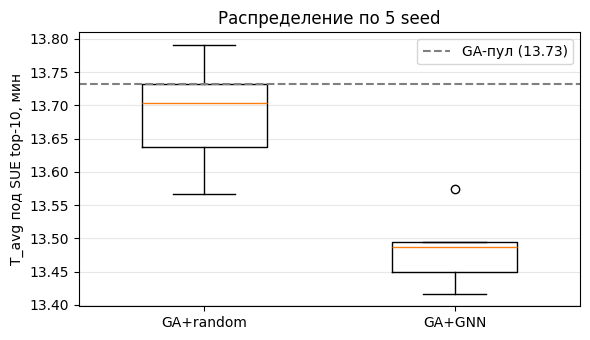

In [26]:
rows=[]
pool_stops=set(s for r in pool for s in r)
for name,net in [('N_pool-top10 (GA-пул под SUE top-10)', N_pool_top10),
                 ('N_pe-random  (GA point-edit, лучший)', N_pe_rnd),
                 ('N_pe-GNN     (GA+GNN point-edit, лучший)', N_pe_gnn)]:
    T=evaluate_sue_topk(net)/60
    esc=len(set(s for r in net for s in r)-pool_stops)
    rows.append(dict(Метод=name, T_avg_мин=round(T,2), Маршрутов=len(net), Остановок_вне_пула=esc))
res=pd.DataFrame(rows); display(res)

print(f"Выигрыш GA+GNN относительно GA-пул: {(T_pool_top10/60 - T_gnn.min()):.2f} мин ({(T_pool_top10/60-T_gnn.min())/(T_pool_top10/60)*100:+.1f}%)")
print(f"Выигрыш GA+GNN относительно GA+random (best): {(T_rnd.min() - T_gnn.min()):.2f} мин")

# боксплот по 5 seed
plt.figure(figsize=(6,3.5))
plt.boxplot([T_rnd, T_gnn], tick_labels=['GA+random', 'GA+GNN'], widths=0.5)
plt.axhline(T_pool_top10/60, ls='--', color='gray', label=f'GA-пул ({T_pool_top10/60:.2f})')
plt.ylabel('T_avg под SUE top-10, мин'); plt.title('Распределение по 5 seed')
plt.legend(); plt.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## 13. Экспорт лучшей GNN-сети (отдельный слой, чтобы не затирать прошлые)

In [27]:
def route_polyline(route):
    node_seq=[board_nodes[s] for s in route]+[metro_nodes[0]]; coords=[]
    for a,b in zip(node_seq[:-1],node_seq[1:]):
        try: path=nx.shortest_path(G,a,b,weight='time')
        except nx.NetworkXNoPath: continue
        coords+= path if not coords else path[1:]
    return LineString(coords) if len(coords)>=2 else None
gdf=gpd.GeoDataFrame([dict(route_id=i+1,n_stops=len(r),geometry=route_polyline(r))
                      for i,r in enumerate(N_pe_gnn) if route_polyline(r)], crs=CRS)
gdf.to_file(PATHS['out'], layer='gnn_top10_routes', driver='GPKG')
served_idx=sorted(set(s for r in N_pe_gnn for s in r))
board.iloc[served_idx].to_file(PATHS['out'], layer='gnn_top10_stops', driver='GPKG')
print("Сохранено", PATHS['out'], "слои: gnn_top10_routes, gnn_top10_stops")

Сохранено C:\Users\georg\NIS\Curse_work_2026\exp4_gnn_top10_routes.gpkg слои: gnn_top10_routes, gnn_top10_stops


## 14. Визуализация
Сравнение трёх сетей на одной карте: пул-ГА (тонкие), point-edit best random (средние),
point-edit best GNN (толстые, цветные). Розовые маркеры — остановки вне исходного пула.

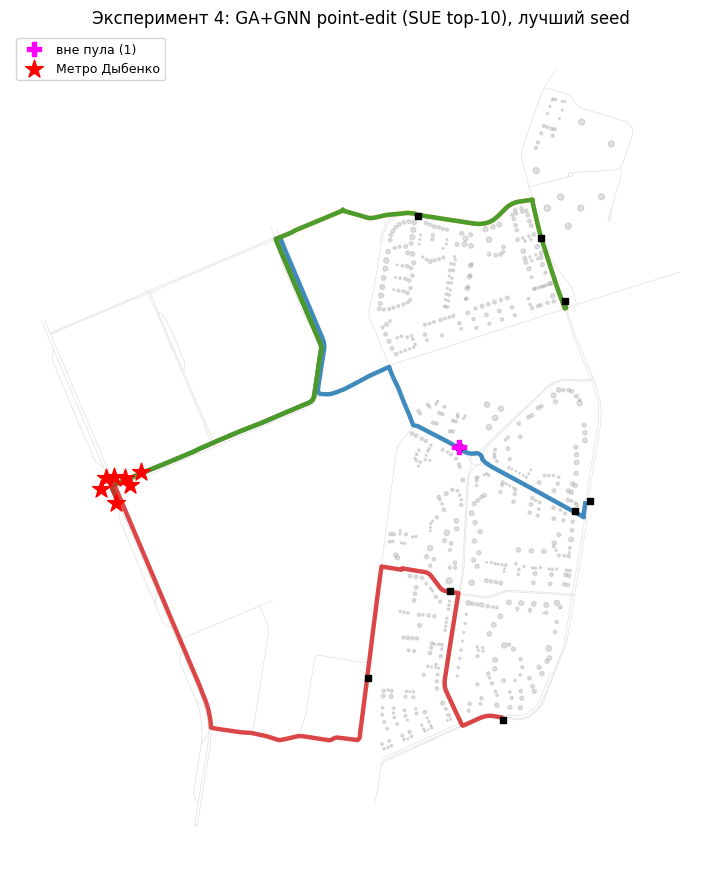

In [28]:
roads=gpd.read_file(PATHS['roads'],layer='doroga_for_busiki').to_crs(CRS)
fig,ax=plt.subplots(figsize=(11,9)); roads.plot(ax=ax,color='0.88',lw=0.5,zorder=1)
ent.plot(ax=ax,color='0.6',markersize=ent['population']/30,alpha=0.3,zorder=2)
cmap=plt.cm.tab10
for i,r in enumerate(N_pe_gnn):
    g=route_polyline(r)
    if g: gpd.GeoSeries([g],crs=CRS).plot(ax=ax,color=cmap(i%10),lw=3.2,zorder=5,alpha=0.85)
esc=sorted(set(s for r in N_pe_gnn for s in r)-pool_stops)
board.iloc[served_idx].plot(ax=ax,color='black',markersize=22,marker='s',zorder=6)
if esc: board.iloc[esc].plot(ax=ax,color='magenta',markersize=90,marker='P',zorder=7,label=f'вне пула ({len(esc)})')
metro.plot(ax=ax,color='red',markersize=180,marker='*',zorder=8,label='Метро Дыбенко')
ax.legend(loc='upper left',fontsize=9); ax.set_title('Эксперимент 4: GA+GNN point-edit (SUE top-10), лучший seed')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 15. Что показывает эксперимент (для выводов курсовой)

- **Расширение окна выбора (top-3 → top-10) — содержательное.** Сеть, оптимальная под top-3,
  под более реалистичным top-10 SUE заметно проигрывает: пассажирам реально доступно больше
  альтернатив, и узкая модель этого не видит.
- **Выход за пул (point-edit) помогает.** Даже со случайной мутацией ГА с точечными правками
  находит сети, ощутимо лучше пул-ограниченного ГА — а в составе сетей появляются остановки,
  которых не было ни в одном маршруте из 39 кандидатов.
- **GNN-направленная мутация улучшает результат ещё раз.** В среднем по 5 seed GNN-вариант
  стабильно лучше случайного, и его лучший seed бьёт лучший random. Источник выигрыша —
  bipartite-этап A (подъезд↔остановка), который через `gap`-признак на ребре «видит», у каких
  подъездов реально нет альтернатив, и направляет правки в их пользу.
- **Это первое реальное преимущество GNN-добавки** относительно полностью эквивалентного random
  baseline на нашей задаче (в эксп. 3 при top-3 преимущества не было: окно выбора было слишком
  узким, чтобы политика могла его эксплуатировать).

### Ограничения
- Один город (Кудрово). Обобщение на другие агломерации не проверено — для этого нужна
  индуктивная архитектура и данные нескольких пригородов.
- REINFORCE шумен; число seed (5) маленькое — для серьёзной работы стоит запустить 10–20.
- Точечные правки ограничены k-NN соседями (k=6). Расширение k может дать больше пространства.


## 16. Подсчет T_avg в текущих условиях

In [34]:
# Существующая сеть и бейзлайн под SUE-логит, top-10
ROUTES_EXISTING = [
    [13,38,14,9,10,19,28,27,7,25,43,42,3,2],
    [40,24,16,23,15,22],
    [17,29,8,26,42,3,2],
    [37,28,27,30,18,21,5],
]
ROUTES_BASELINE = [
    [12,21,1,40,16,15],
    [13,14,9,19,27,7,43,3],
    [13,8,26,3],
    [37,27,30,21],
    [42,3,41,39],
]

T_existing_top10 = evaluate_sue_topk(ROUTES_EXISTING) / 60
T_baseline_top10 = evaluate_sue_topk(ROUTES_BASELINE) / 60
print(f"Существующая сеть | SUE-логит top-10: T_avg = {T_existing_top10:.2f} мин")
print(f"Бейзлайн          | SUE-логит top-10: T_avg = {T_baseline_top10:.2f} мин")
print(f"Для сравнения: ГА-пул top-10 = 13.73 мин, GA+GNN top-10 = 13.42–13.48 мин")

Существующая сеть | SUE-логит top-10: T_avg = 15.89 мин
Бейзлайн          | SUE-логит top-10: T_avg = 15.58 мин
Для сравнения: ГА-пул top-10 = 13.73 мин, GA+GNN top-10 = 13.42–13.48 мин


## 17. Дополнительные метрики

In [36]:
# === Дополнительные метрики (медиана/P90/minimax/"пешком быстрее"), top-10 ===
import os

def evaluate_sue_topk_detailed(routes):
    """Копия evaluate_sue_topk, но дополнительно возвращает et (T_i по подъездам, сек) и served_pct."""
    if not routes: return np.inf, None, 0.0
    Kn=len(routes); pr=[precompute_route(r) for r in routes]
    stop_routes=defaultdict(list)
    for rid,d in enumerate(pr):
        for s,t in d.items(): stop_routes[s].append((rid,t))
    cyc=np.array([2*route_oneway_time(r)*P['layover_factor'] for r in routes]); seats_avg=sum(FLEET)/len(FLEET)
    Nveh=np.maximum(1,np.full(Kn,len(FLEET)//Kn))
    while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
    while Nveh.sum()<len(FLEET): Nveh[np.argmin(Nveh)]+=1
    flow=np.zeros(Kn); prob=has=U=served=None
    for it in range(1,SUE['msa_iters']+1):
        headway=cyc/np.maximum(Nveh,1); freq=1.0/headway
        stop_cost=np.full(nstops,np.inf); board_split={}
        for s,lst in stop_routes.items():
            items=sorted([(t,rid) for rid,t in lst]); f=ft=0.0; bestC=np.inf; chosen=[]
            for teff,rid in items:
                f2=f+freq[rid]; ft2=ft+freq[rid]*teff; C=(SUE['w0']+ft2)/f2
                if C<=bestC+1e-9: bestC=C; f=f2; ft=ft2; chosen.append(rid)
                else: break
            stop_cost[s]=bestC; fs=sum(freq[r] for r in chosen)
            board_split[s]={r:freq[r]/fs for r in chosen}
        U=TWALK+stop_cost[B_IDX]; served=np.isfinite(U)
        if not served.any(): break
        shift=np.nanmin(np.where(served,U,np.nan),axis=1,keepdims=True)
        ex=np.where(served,np.exp(-SUE['theta']*(U-shift)),0.0); Z=ex.sum(axis=1,keepdims=True)
        prob=np.where(Z>0,ex/Z,0.0); has=(Z[:,0]>0)
        demand=POP*P['commuter_share']; stop_in=np.zeros(nstops)
        for c in range(TOPK): np.add.at(stop_in,B_IDX[:,c],demand*prob[:,c])
        aux=np.zeros(Kn)
        for s,split in board_split.items():
            for r,p in split.items(): aux[r]+=stop_in[s]*p
        step=1.0/it; new=flow+step*(aux-flow); gap=np.sum(np.abs(new-flow))/max(np.sum(new),1); flow=new
        w=np.sqrt(np.maximum(flow/P['peak_hours'],1)); Nveh=np.maximum(1,np.round(w/w.sum()*len(FLEET)).astype(int))
        while Nveh.sum()>len(FLEET): Nveh[np.argmax(Nveh)]-=1
        while Nveh.sum()<len(FLEET): Nveh[np.argmax(flow)]+=1
        if gap<SUE['msa_tol'] and it>5: break
    et=np.where(has,(prob*np.where(served,U,0)).sum(axis=1),P['unserved_penalty_s'])
    Tavg=float((POP*et).sum()/POP.sum())
    return Tavg, et, float(POP[has].sum()/POP.sum()*100)


def weighted_percentile(values, weights, q):
    order = np.argsort(values)
    v, w = values[order], weights[order]
    cw = np.cumsum(w); cw /= cw[-1]
    return float(np.interp(q/100, cw, v))


PODYEZD_DIST_PATH = r"C:\Users\georg\NIS\Curse_work_2026\podyezd_dist_to_metro.csv"  # поправьте при необходимости

def extra_metrics(name, routes):
    Tavg, et, served_pct = evaluate_sue_topk_detailed(routes)
    median_t = weighted_percentile(et, POP, 50)
    p90_t    = weighted_percentile(et, POP, 90)
    served = et < P['unserved_penalty_s']
    minimax_all    = et.max()
    minimax_served = et[served].max() if served.any() else np.nan

    print(f"--- {name} ---")
    print(f"T_avg = {Tavg/60:.2f} мин | обслужено {served_pct:.1f}%")
    metrics = pd.DataFrame([
        dict(Метрика='T_avg (среднее)',       Значение_мин=round(Tavg/60, 2)),
        dict(Метрика='Медиана',               Значение_мин=round(median_t/60, 2)),
        dict(Метрика='P90',                   Значение_мин=round(p90_t/60, 2)),
        dict(Метрика='Minimax (все)',         Значение_мин=round(minimax_all/60, 2)),
        dict(Метрика='Minimax (обслуженные)', Значение_мин=round(minimax_served/60, 2)),
    ])
    display(metrics)

    if os.path.exists(PODYEZD_DIST_PATH):
        walk_df = pd.read_csv(PODYEZD_DIST_PATH)
        id_col   = next((c for c in walk_df.columns if c.lower() in ('entrance_id','id','fid','podyezd','podyezd_id')), walk_df.columns[0])
        dist_col = next((c for c in walk_df.columns if 'dist' in c.lower()), walk_df.columns[1])
        walk_df = walk_df[[id_col, dist_col]].rename(columns={id_col:'entrance_id', dist_col:'dist_m'})
        walk_df['t_walk_direct_s'] = walk_df['dist_m'] / P['walk_speed_mps']

        cmp_df = pd.DataFrame({'entrance_id': EIDS, 'population': POP, 't_bus_s': et})
        cmp_df = cmp_df.merge(walk_df[['entrance_id','t_walk_direct_s']], on='entrance_id', how='left').dropna(subset=['t_walk_direct_s'])

        walk_faster = cmp_df['t_walk_direct_s'] < cmp_df['t_bus_s']
        pct_pop = cmp_df.loc[walk_faster,'population'].sum() / cmp_df['population'].sum() * 100
        print(f"Подъездов, где пешком быстрее: {walk_faster.sum()} / {len(cmp_df)} ({pct_pop:.1f}% населения)")
    else:
        print(f"[пропущено: не найден {PODYEZD_DIST_PATH}]")
    print()
    return metrics

extra_metrics("N_pool-top10 (GA-пул под SUE top-10)", N_pool_top10)
extra_metrics("N_pe-random (GA point-edit, лучший)", N_pe_rnd)
extra_metrics("N_pe-GNN (GA+GNN point-edit, лучший)", N_pe_gnn)

--- N_pool-top10 (GA-пул под SUE top-10) ---
T_avg = 13.73 мин | обслужено 100.0%


,Метрика,Значение_мин
0,T_avg (среднее),13.73
1,Медиана,13.38
2,P90,16.99
3,Minimax (все),21.63
4,Minimax (обслуженные),21.63


Подъездов, где пешком быстрее: 0 / 620 (0.0% населения)

--- N_pe-random (GA point-edit, лучший) ---
T_avg = 13.57 мин | обслужено 100.0%


,Метрика,Значение_мин
0,T_avg (среднее),13.57
1,Медиана,13.42
2,P90,16.09
3,Minimax (все),20.96
4,Minimax (обслуженные),20.96


Подъездов, где пешком быстрее: 0 / 620 (0.0% населения)

--- N_pe-GNN (GA+GNN point-edit, лучший) ---
T_avg = 13.42 мин | обслужено 100.0%


,Метрика,Значение_мин
0,T_avg (среднее),13.42
1,Медиана,13.34
2,P90,16.30
3,Minimax (все),21.03
4,Minimax (обслуженные),21.03


Подъездов, где пешком быстрее: 0 / 620 (0.0% населения)



,Метрика,Значение_мин
0,T_avg (среднее),13.42
1,Медиана,13.34
2,P90,16.30
3,Minimax (все),21.03
4,Minimax (обслуженные),21.03
